In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [4]:
df = pd.read_csv("netflix_titles.csv")

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 12


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna("Unknown")

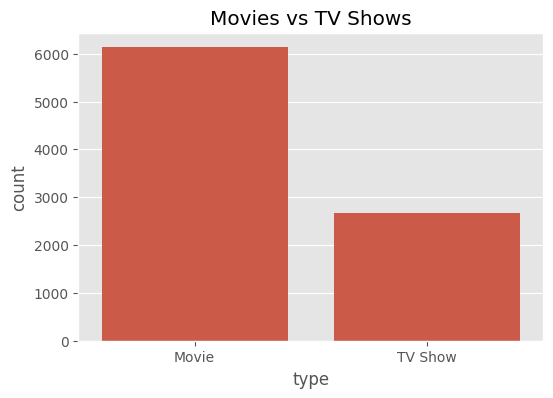

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.show()

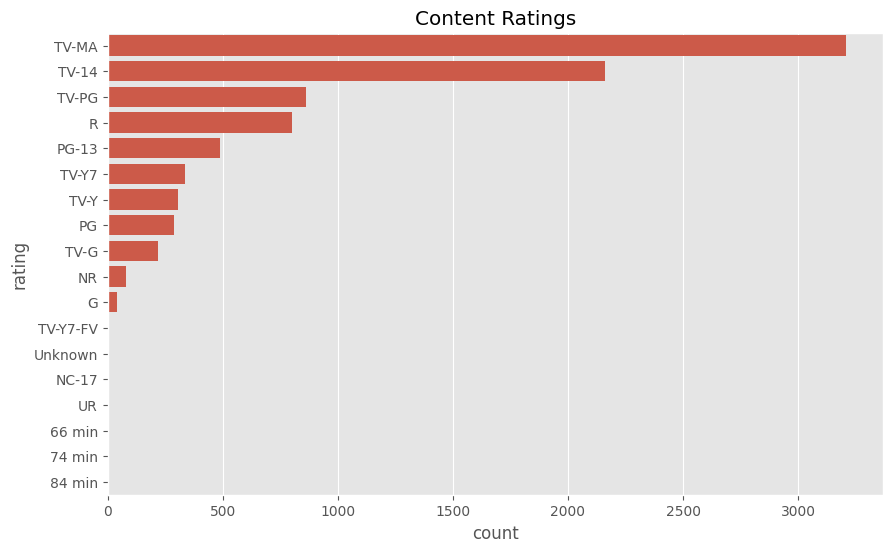

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index
)
plt.title("Content Ratings")
plt.show()

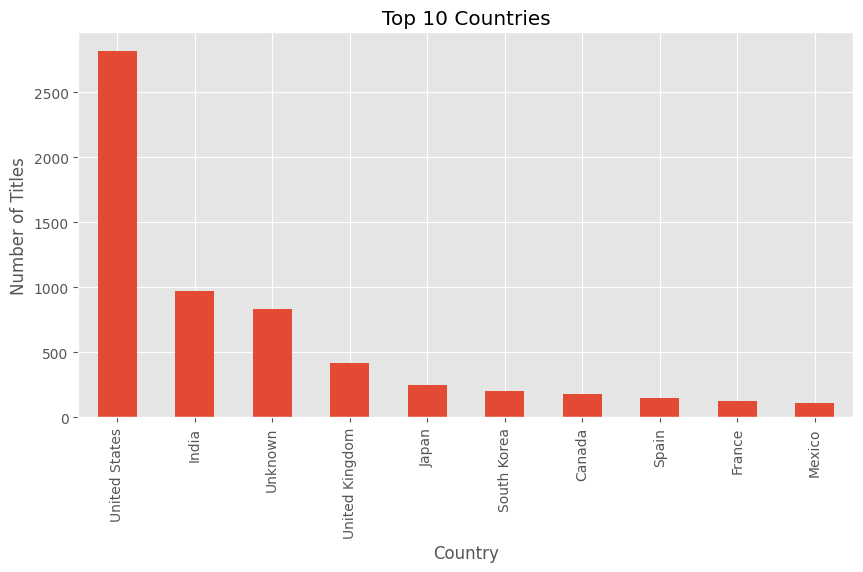

In [11]:
top_country = df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_country.plot(kind="bar")
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

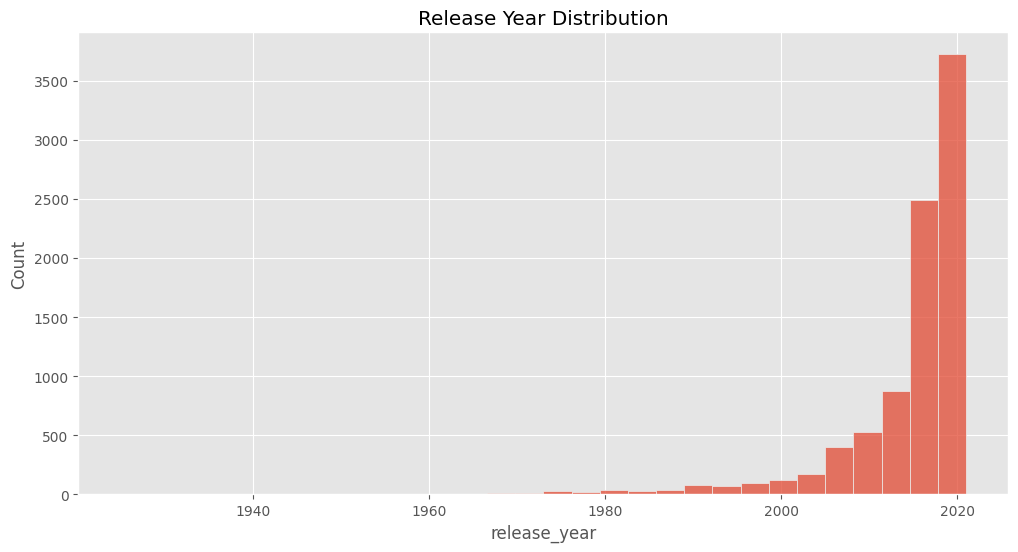

In [12]:
plt.figure(figsize=(12,6))
sns.histplot(df["release_year"], bins=30)
plt.title("Release Year Distribution")
plt.show()

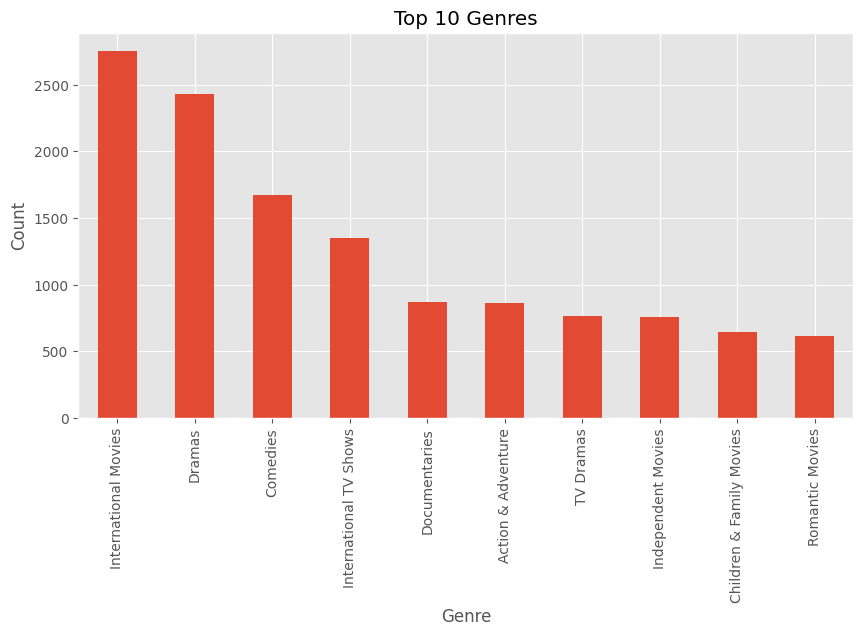

In [13]:
genres = df["listed_in"].str.split(", ").explode()

plt.figure(figsize=(10,5))
genres.value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

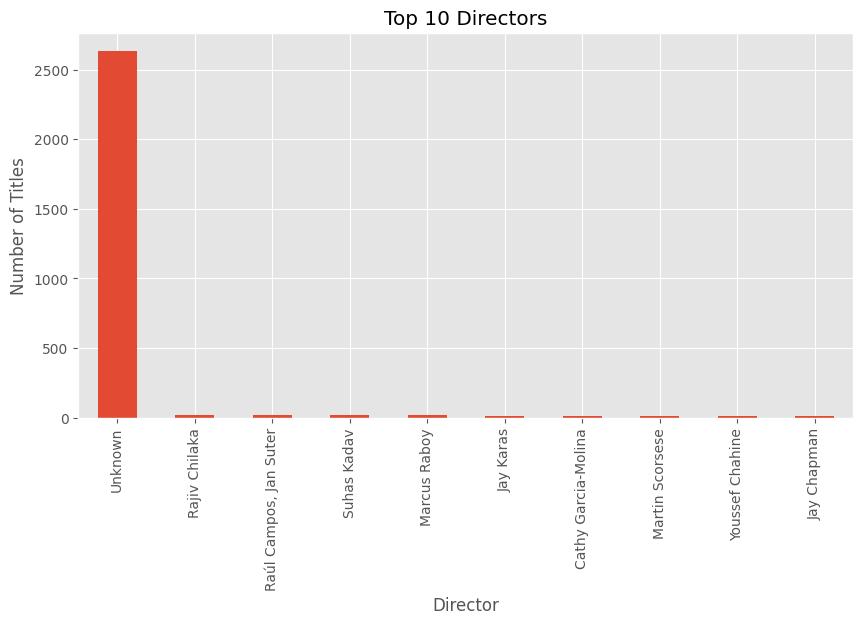

In [14]:
plt.figure(figsize=(10,5))
df["director"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Directors")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.show()

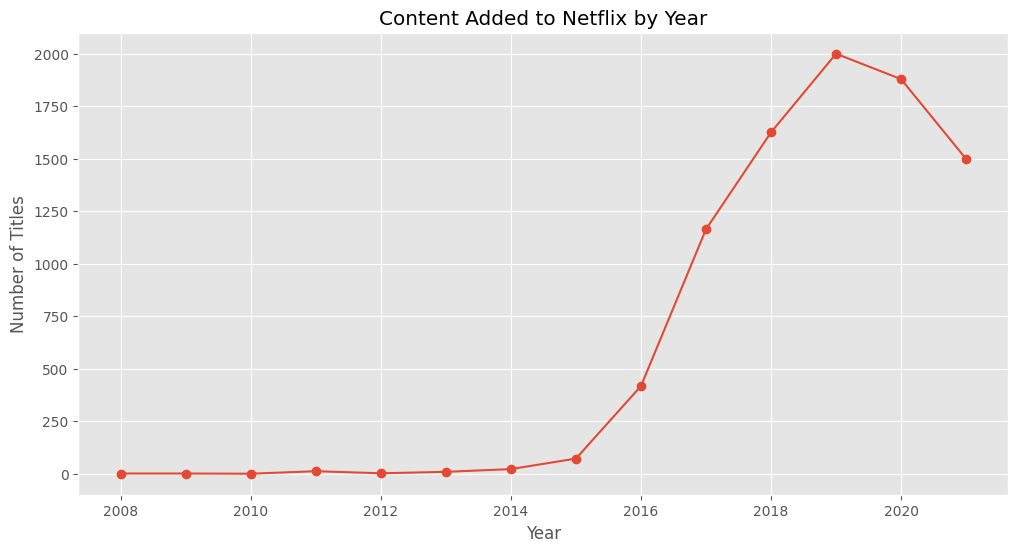

In [15]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["added_year"] = df["date_added"].dt.year

plt.figure(figsize=(12,6))
df["added_year"].value_counts().sort_index().plot(marker="o")
plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

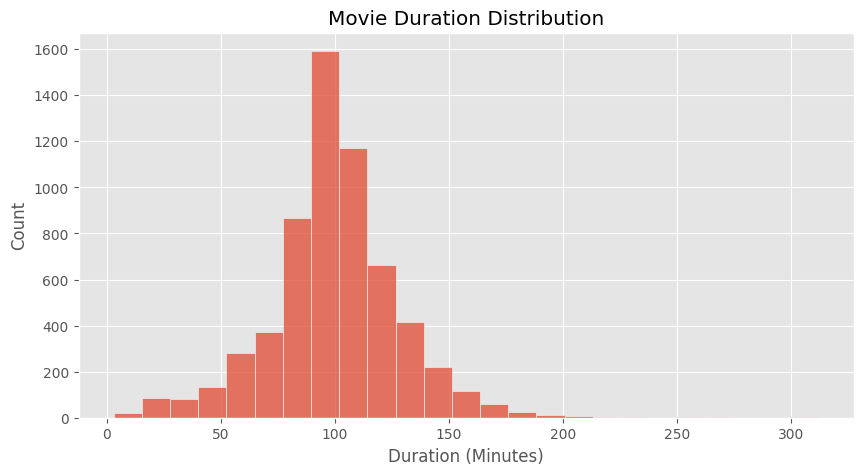

In [16]:
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

plt.figure(figsize=(10,5))
sns.histplot(movies["duration"], bins=25)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.show()

In [17]:
movies[["title", "duration"]].sort_values(by="duration", ascending=False).head(10)

,title,duration
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0
2488,Raya and Sakina,230.0
166,Once Upon a Time in America,229.0
7932,Sangam,228.0
1019,Lagaan,224.0
4573,Jodhaa Akbar,214.0


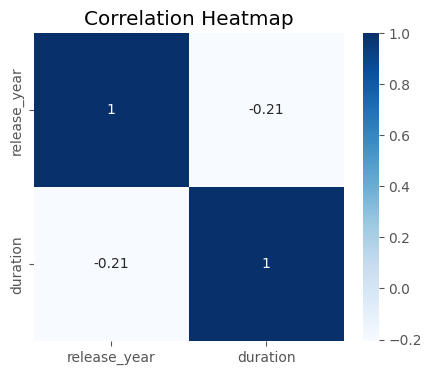

In [18]:
numeric = movies[["release_year", "duration"]]

plt.figure(figsize=(5,4))
sns.heatmap(numeric.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

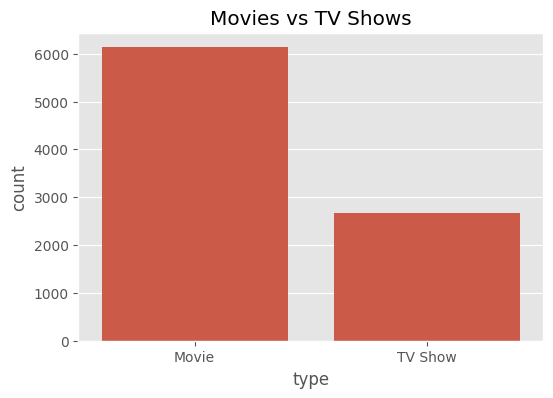

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.savefig("movies_vs_tvshows.png", dpi=300)
plt.show()